In [23]:
# ==========================================
# TASK 2 - EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [24]:
# Load Dataset
df = pd.read_csv("Titanic-Dataset.csv")

# ==========================================
# BASIC INFORMATION
# ==========================================

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())



First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

In [15]:
# ==========================================
# SUMMARY STATISTICS
# ==========================================

print("\nSummary Statistics")
print(df.describe())

print("\nMedian")
print(df.median(numeric_only=True))








Summary Statistics
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Median
PassengerId    446.0000
Survived         0.0000
Pclas

In [16]:
# ==========================================
# DATA CLEANING
# ==========================================

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Cabin has too many missing values
df.drop('Cabin', axis=1, inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())



Missing Values After Cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_179871/719439433.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_179871/719439433.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

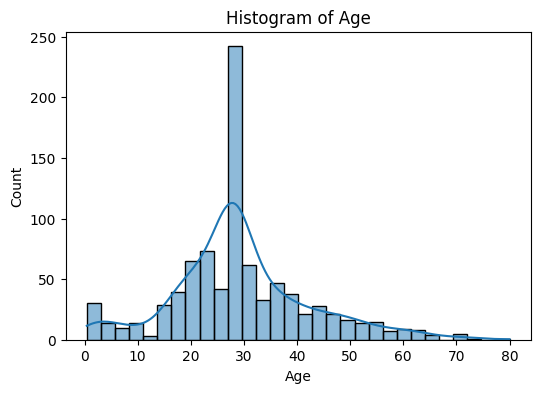

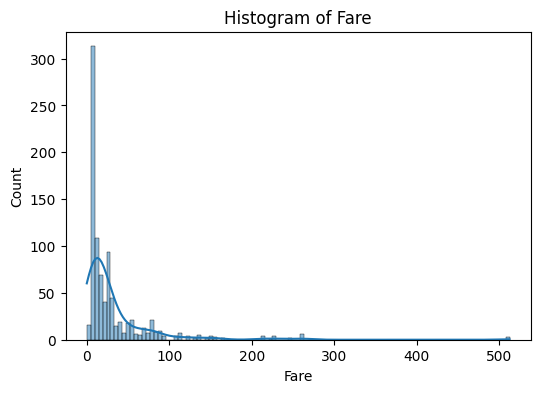

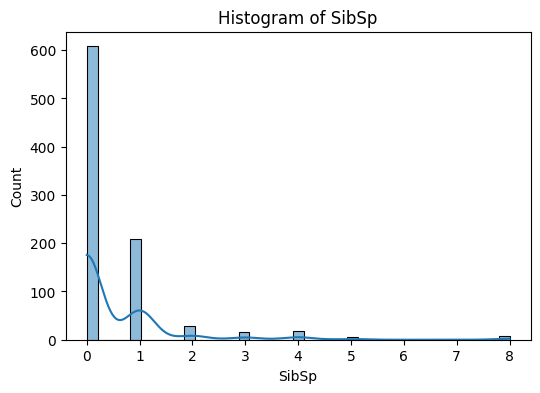

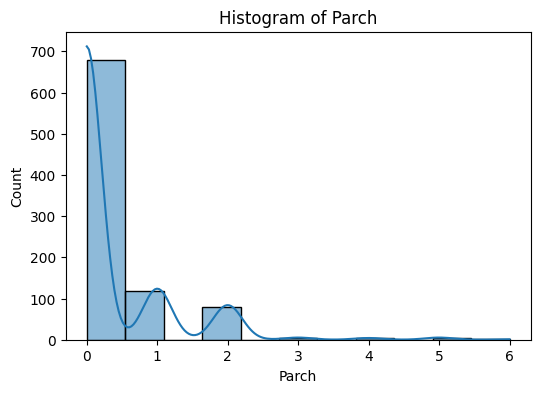

In [17]:
# ==========================================
# HISTOGRAMS
# ==========================================

numeric_cols = ['Age','Fare','SibSp','Parch']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

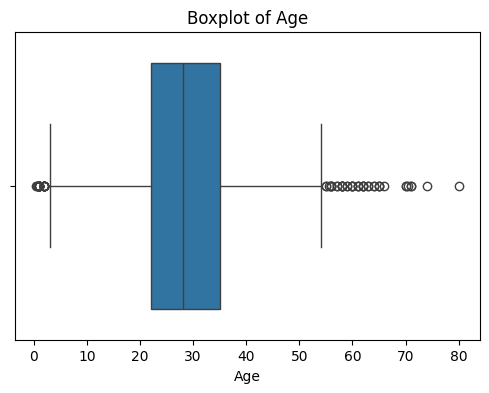

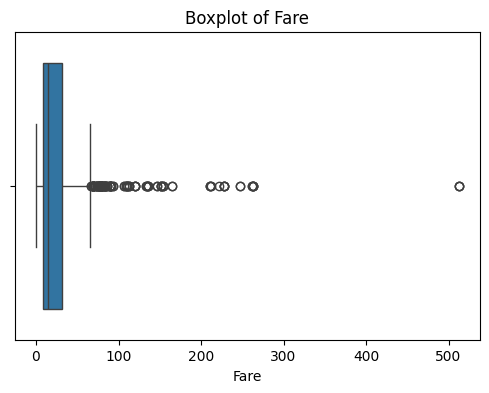

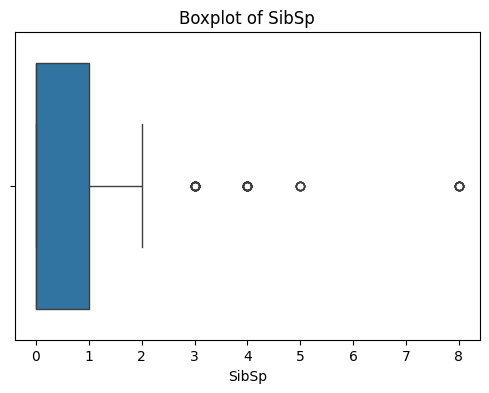

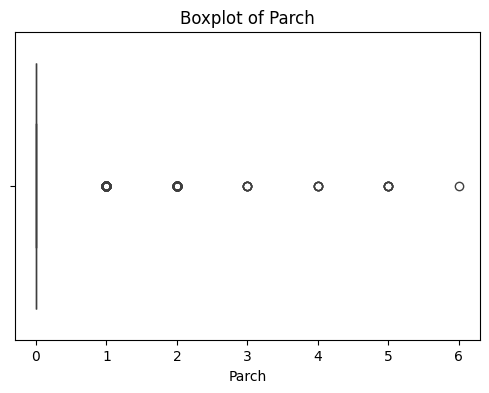

In [18]:
# ==========================================
# BOXPLOTS
# ==========================================

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


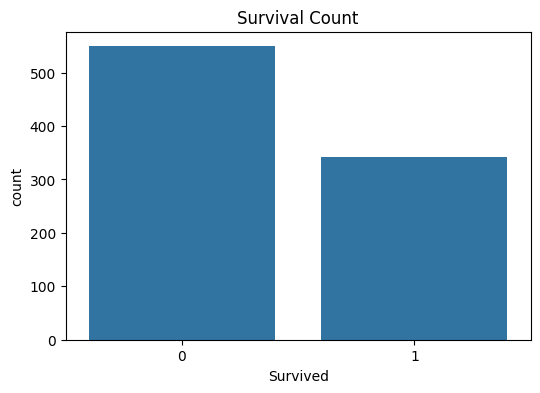

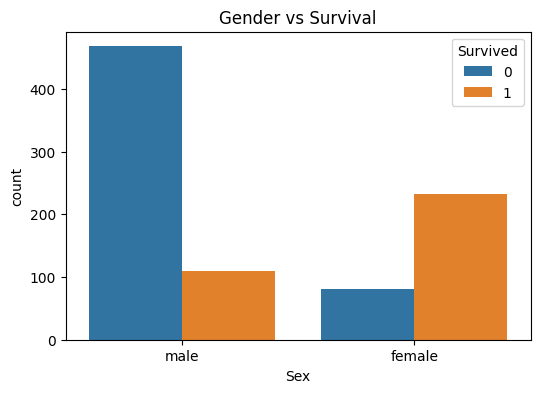

In [19]:
# ==========================================
# SURVIVAL COUNT
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# ==========================================
# GENDER VS SURVIVAL
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()


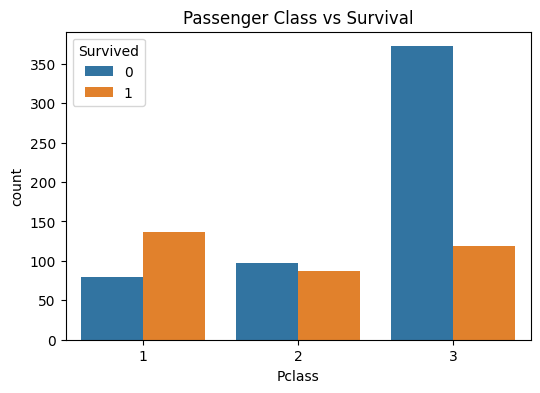

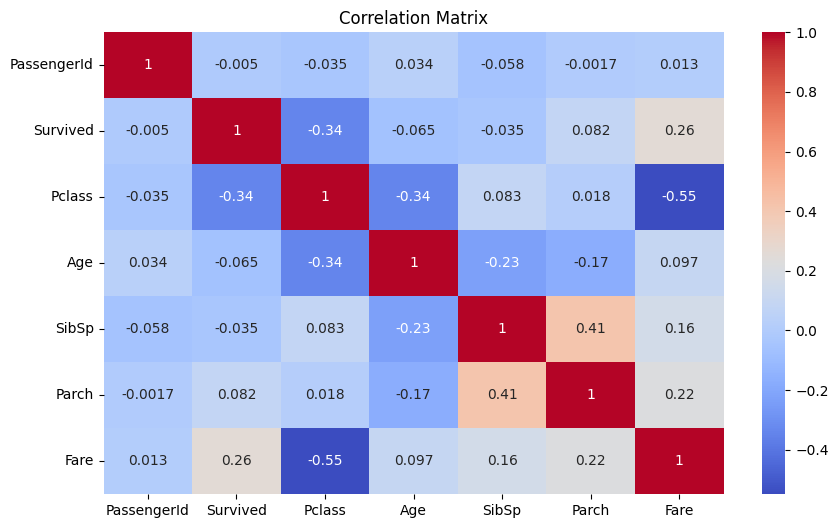

In [20]:
# ==========================================
# PASSENGER CLASS VS SURVIVAL
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

# ==========================================
# CORRELATION MATRIX
# ==========================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

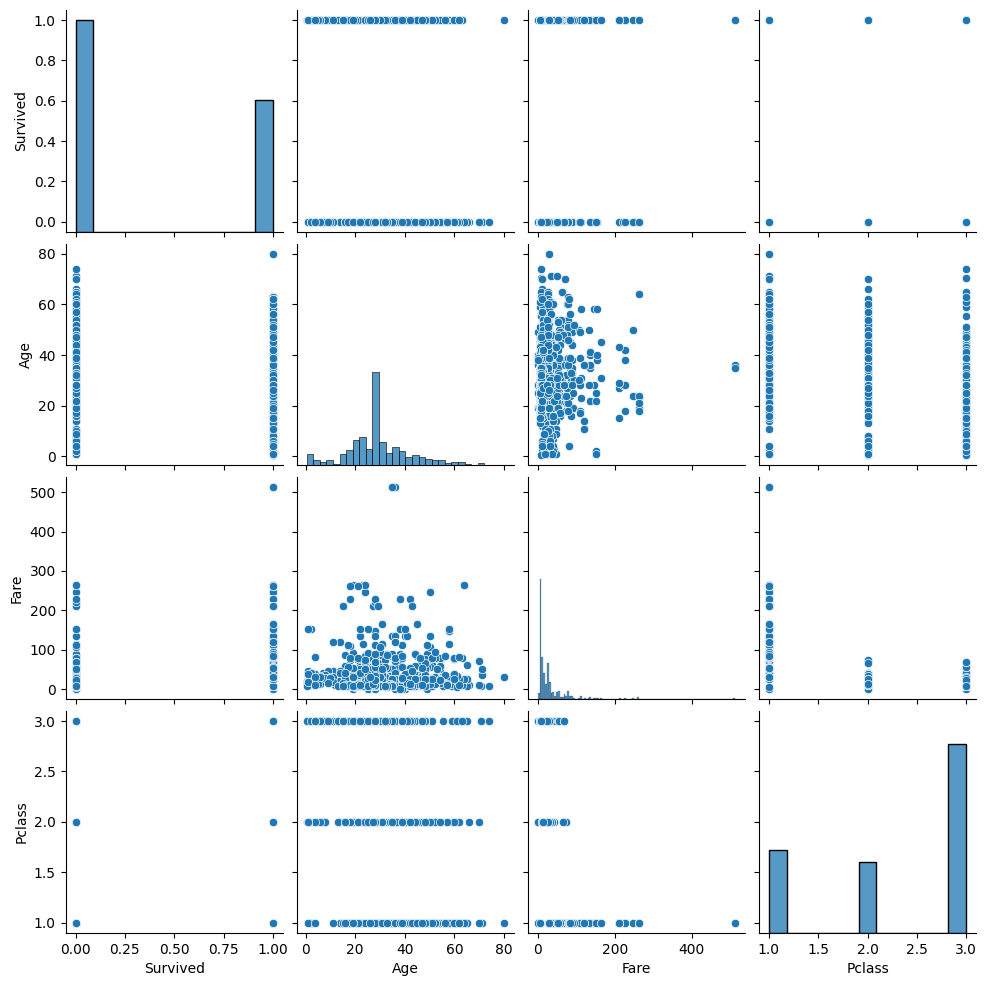


Skewness
Age : 0.5102446555756495
Fare : 4.787316519674893
SibSp : 3.6953517271630565
Parch : 2.7491170471010933


In [21]:
# ==========================================
# PAIRPLOT
# ==========================================

sns.pairplot(
    df[['Survived','Age','Fare','Pclass']]
)
plt.show()

# ==========================================
# SKEWNESS
# ==========================================

print("\nSkewness")

for col in numeric_cols:
    print(col, ":", df[col].skew())


In [22]:
# ==========================================
# OUTLIERS
# ==========================================

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]

print("\nNumber of Fare Outliers:")
print(len(outliers))

# ==========================================
# INFERENCES
# ==========================================

print("\nKey Insights")
print("1. Females survived more than males.")
print("2. Higher-class passengers had higher survival rates.")
print("3. Fare contains significant outliers.")
print("4. Age distribution is slightly right-skewed.")
print("5. Fare and Pclass show correlation.")


Number of Fare Outliers:
116

Key Insights
1. Females survived more than males.
2. Higher-class passengers had higher survival rates.
3. Fare contains significant outliers.
4. Age distribution is slightly right-skewed.
5. Fare and Pclass show correlation.
